# Speech Emotion Recognition - Fine-Tuning wav2vec 2.0

This notebook fine-tunes Facebook's wav2vec 2.0 (base) model on the TESS dataset
for speech emotion classification.

wav2vec 2.0 is a self-supervised transformer pre-trained on 960 hours of unlabelled
speech (LibriSpeech). Its convolutional feature encoder transforms raw waveforms
into latent representations, which are then contextualised by a transformer encoder.
For downstream classification we freeze the CNN encoder and fine-tune only the
transformer layers together with a newly added classification head.

Key design decisions:
- Freeze feature extractor weights to stabilise early fine-tuning
- Use a mean-pooling aggregation over time steps before the classification head
- Apply label smoothing and dropout for regularisation
- Warm-up learning rate schedule to avoid destabilising pre-trained weights

Dataset: Toronto Emotional Speech Set (TESS)
Model: facebook/wav2vec2-base (from Hugging Face Hub)

#0. load Kaggle dataset


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"KAGGLE_API_TOKEN":"KGAT_046a3492e5c84ea2d9feb59e2304277e"}'}

In [ ]:
# load the dataset from kaggle website
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio

Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
100% 429M/429M [00:23<00:00, 19.1MB/s]



In [ ]:
# unzip the dataset
!unzip /content/ravdess-emotional-speech-audio.zip -d /content/dataset

Archive:  /content/ravdess-emotional-speech-audio.zip
  inflating: /content/dataset/Actor_01/03-01-01-01-01-01-01.wav  
  inflating: /content/dataset/Actor_01/03-01-01-01-01-02-01.wav  
  inflating: /content/dataset/Actor_01/03-01-01-01-02-01-01.wav  
  inflating: /content/dataset/Actor_01/03-01-01-01-02-02-01.wav  
  inflating: /content/dataset/Actor_01/03-01-02-01-01-01-01.wav  
  inflating: /content/dataset/Actor_01/03-01-02-01-01-02-01.wav  
  inflating: /content/dataset/Actor_01/03-01-02-01-02-01-01.wav  
  inflating: /content/dataset/Actor_01/03-01-02-01-02-02-01.wav  
  inflating: /content/dataset/Actor_01/03-01-02-02-01-01-01.wav  
  inflating: /content/dataset/Actor_01/03-01-02-02-01-02-01.wav  
  inflating: /content/dataset/Actor_01/03-01-02-02-02-01-01.wav  
  inflating: /content/dataset/Actor_01/03-01-02-02-02-02-01.wav  
  inflating: /content/dataset/Actor_01/03-01-03-01-01-01-01.wav  
  inflating: /content/dataset/Actor_01/03-01-03-01-01-02-01.wav  
  inflating: /content/

## 1. Install Dependencies

In [ ]:
!pip install transformers datasets accelerate noisereduce soundfile librosa \
    evaluate scikit-learn tqdm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.2 MB/s eta 0:00:00


## 2. Imports

In [ ]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

import librosa
import noisereduce as nr

from transformers import Wav2Vec2Processor, Wav2Vec2Model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Prefer GPU if available
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 3. Configuration

In [ ]:
# Path to the TESS dataset root directory
DATASET_PATH = '/content/dataset'

# Hugging Face model identifier for wav2vec 2.0 base
MODEL_NAME = 'facebook/wav2vec2-base'

# wav2vec 2.0 expects 16 kHz input audio
TARGET_SR = 16000

# Maximum audio duration in seconds; longer clips are truncated
MAX_DURATION = 4.0
MAX_LENGTH = int(MAX_DURATION * TARGET_SR)  # samples

# Training hyper-parameters
BATCH_SIZE = 16
EPOCHS = 8
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-2
DROPOUT = 0.3
LABEL_SMOOTHING = 0.1

# Validation split fraction
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

SEED = 42

# Emotions present in TESS
EMOTIONS = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fear",
    "07": "disgust",
    "08": "surprised"
}
NUM_CLASSES = len(EMOTIONS)

## 4. Audio Cleaning Utilities

The same cleaning pipeline as Notebook 1 is applied here so both models
receive acoustically consistent input.

In [ ]:
def load_and_clean_audio(file_path, target_sr=TARGET_SR):
    """
    Load and clean a single audio file.

    Steps
    -----
    1. librosa.load resamples to target_sr (16 kHz for wav2vec) and converts
       to mono by averaging channels.
    2. noisereduce.reduce_noise performs non-stationary spectral subtraction
       using the first 0.5 s as a noise reference clip.
    3. librosa.effects.trim removes near-silent boundaries.
    4. Pre-emphasis first-order FIR filter sharpens spectral contrast.
    5. RMS normalisation equalises loudness across utterances.
    6. Zero-padding / truncation to MAX_LENGTH ensures a uniform tensor shape
       for batching without a variable-length collator.

    Returns
    -------
    np.ndarray of shape (MAX_LENGTH,) with dtype float32
    """
    y, sr = librosa.load(file_path, sr=target_sr, mono=True)

    # Noise reduction
    noise_clip = y[:int(0.5 * sr)] if len(y) > int(0.5 * sr) else y
    y = nr.reduce_noise(y=y, sr=sr, y_noise=noise_clip,
                        prop_decrease=0.75, stationary=False)

    # Silence trimming
    y, _ = librosa.effects.trim(y, top_db=30)
    if len(y) == 0:
        y, _ = librosa.load(file_path, sr=target_sr, mono=True)

    # Pre-emphasis
    y = np.append(y[0], y[1:] - 0.97 * y[:-1])

    # RMS normalisation
    rms = np.sqrt(np.mean(y ** 2))
    if rms > 0:
        y = y * (0.1 / rms)

    # Pad or truncate to a fixed length so all tensors have the same shape
    if len(y) < MAX_LENGTH:
        y = np.pad(y, (0, MAX_LENGTH - len(y)), mode='constant')
    else:
        y = y[:MAX_LENGTH]

    return y.astype(np.float32)

## 5. Dataset Class

In [ ]:
class TESSDataset(Dataset):
    """
    PyTorch Dataset wrapper around the TESS audio files.

    The Wav2Vec2Processor handles feature normalisation (mean/variance
    normalisation of the raw waveform) which is required before passing
    audio to the model. The processor was fitted on 16 kHz LibriSpeech
    audio, matching our TARGET_SR.

    Parameters
    ----------
    file_paths : list[str]   Paths to .wav files
    labels     : list[int]   Integer class labels
    processor  : Wav2Vec2Processor  Normaliser + tokeniser
    """

    def __init__(self, file_paths, labels, processor):
        self.file_paths = file_paths
        self.labels = labels
        self.processor = processor

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # Load and clean the audio signal
        waveform = load_and_clean_audio(self.file_paths[idx])

        # Wav2Vec2Processor normalises the raw float array and returns
        # a dict with key 'input_values' (a torch Tensor)
        inputs = self.processor(
            waveform,
            sampling_rate=TARGET_SR,
            return_tensors='pt',
            padding=False
        )
        input_values = inputs['input_values'].squeeze(0)  # (T,)

        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return input_values, label

## 6. Model Architecture

In [ ]:
class Wav2Vec2ForEmotionClassification(nn.Module):
    """
    Emotion classifier built on top of the wav2vec 2.0 encoder.

    Architecture
    ------------
    Wav2Vec2Model (transformer encoder)
      -> mean pool over time frames        (B, T, 768) -> (B, 768)
      -> LayerNorm + Dropout
      -> Linear(768, 256) + GELU activation
      -> Dropout
      -> Linear(256, num_classes)

    The CNN feature extractor inside wav2vec is kept frozen to preserve
    low-level acoustic representations that generalise well across tasks.
    Only the transformer encoder layers receive gradients.

    Parameters
    ----------
    model_name  : str  Hugging Face model identifier
    num_classes : int  Number of emotion categories
    dropout     : float  Dropout probability in the classification head
    """

    def __init__(self, model_name, num_classes, dropout=DROPOUT):
        super().__init__()

        # Load the pre-trained wav2vec 2.0 base encoder
        self.wav2vec2 = Wav2Vec2Model.from_pretrained(model_name)

        # Freeze the convolutional feature extractor (first 7 conv layers).
        # These layers are already well-trained for general audio and freezing
        # them reduces over-fitting on the relatively small TESS set.
        self.wav2vec2.feature_extractor._freeze_parameters()

        hidden_size = self.wav2vec2.config.hidden_size  # 768 for base

        # Classification head
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_values, attention_mask=None):
        """
        Forward pass.

        Parameters
        ----------
        input_values  : (B, T) float tensor - normalised waveform
        attention_mask: (B, T) bool tensor  - 1 for valid, 0 for padding

        Returns
        -------
        logits: (B, num_classes)
        """
        # Extract contextualised representations from the transformer
        outputs = self.wav2vec2(
            input_values=input_values,
            attention_mask=attention_mask
        )
        hidden_states = outputs.last_hidden_state  # (B, T', 768)

        # Mean pooling aggregates the variable-length sequence into a
        # single fixed-length vector per utterance.
        if attention_mask is not None:
            # Mask out padding positions before averaging
            mask = attention_mask.unsqueeze(-1).float()
            pooled = (hidden_states * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        else:
            pooled = hidden_states.mean(dim=1)

        return self.classifier(pooled)

## 7. Load Data & Build DataLoaders

In [ ]:
def discover_files(dataset_path):
    """
    Walk the RAVDESS directory tree and collect:
        - file path
        - emotion label
        - actor ID

    RAVDESS filename format:
        03-01-05-01-02-02-12.wav

    Position meanings:
        1. Modality
        2. Vocal channel
        3. Emotion
        4. Emotional intensity
        5. Statement
        6. Repetition
        7. Actor

    Example:
        03-01-05-01-02-02-12.wav
                    ^^ emotion = angry
                                ^^ actor = 12
    """

    records = []

    for path in glob.glob(os.path.join(dataset_path, '**', '*.wav'), recursive=True):

        filename = os.path.splitext(os.path.basename(path))[0]

        parts = filename.split('-')

        # safety check
        if len(parts) != 7:
            continue

        emotion_code = parts[2]
        actor_id = int(parts[6])

        if emotion_code in EMOTIONS:

            records.append({
                'path': path,
                'emotion': EMOTIONS[emotion_code],
                'actor': actor_id
            })

    return pd.DataFrame(records)


# Load dataset
df = discover_files(DATASET_PATH)

print(f'Total audio files found: {len(df)}')
print("\nEmotion distribution:")
print(df['emotion'].value_counts())

print("\nActors:")
print(sorted(df['actor'].unique()))

# Encode string labels to integers
le = LabelEncoder()
df['label'] = le.fit_transform(df['emotion'])

# Two-step stratified split: train / val / test
train_df, temp_df = train_test_split(
    df, test_size=VAL_SPLIT + TEST_SPLIT,
    random_state=SEED, stratify=df['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5,
    random_state=SEED, stratify=temp_df['label']
)

print(f'Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}')

Total audio files found: 2880

Emotion distribution:
emotion
happy        384
sad          384
angry        384
fear         384
surprised    384
calm         384
disgust      384
neutral      192
Name: count, dtype: int64

Actors:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Train: 2016, Val: 432, Test: 432


In [ ]:
# Load the Wav2Vec2 processor that handles normalisation.
# The processor object contains the feature extractor config
# (mean/std for z-score normalisation of raw waveforms).
processor = Wav2Vec2Processor.from_pretrained(MODEL_NAME)

train_ds = TESSDataset(train_df['path'].tolist(), train_df['label'].tolist(), processor)
val_ds   = TESSDataset(val_df['path'].tolist(),   val_df['label'].tolist(),   processor)
test_ds  = TESSDataset(test_df['path'].tolist(),  test_df['label'].tolist(),  processor)

# Since all waveforms are padded/truncated to MAX_LENGTH, a default collate
# function can be used (no dynamic padding needed).
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

## 8. Initialise Model, Optimiser, and Scheduler

In [ ]:
model = Wav2Vec2ForEmotionClassification(MODEL_NAME, NUM_CLASSES).to(DEVICE)

# Count trainable parameters (frozen CNN excluded)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,} total')

# CrossEntropyLoss with label smoothing reduces over-confidence on the
# relatively small TESS training set.
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

# AdamW decouples weight decay from the gradient update, which is important
# for transformer fine-tuning.
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# OneCycleLR warms up the learning rate for the first ~30% of training,
# then anneals it, which is a common strategy for fine-tuning transformers.
scheduler = OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    pct_start=0.3   # 30% warm-up
)

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.bias             | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Trainable params: 90,371,720 / 94,572,168 total


## 9. Training Loop

In [ ]:
def run_epoch(model, loader, criterion, optimizer, scheduler, train=True):
    """
    Run one epoch of training or evaluation.

    Parameters
    ----------
    model     : nn.Module
    loader    : DataLoader
    criterion : loss function
    optimizer : torch.optim  (ignored when train=False)
    scheduler : LR scheduler (ignored when train=False)
    train     : bool  If True, backpropagate and update weights.

    Returns
    -------
    (avg_loss, accuracy) for the epoch
    """
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    context = torch.enable_grad if train else torch.no_grad
    with context():
        for batch in tqdm(loader, desc='train' if train else 'eval', leave=False):
            inputs, labels = batch
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)

            if train:
                optimizer.zero_grad()

            logits = model(inputs)
            loss   = criterion(logits, labels)

            if train:
                loss.backward()
                # Gradient clipping prevents exploding gradients in
                # transformer layers during early fine-tuning.
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()

            preds = logits.argmax(dim=-1)
            correct   += (preds == labels).sum().item()
            total     += labels.size(0)
            total_loss += loss.item() * labels.size(0)

    return total_loss / total, correct / total


history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, scheduler, train=True)
    vl_loss, vl_acc = run_epoch(model, val_loader,   criterion, None,      None,      train=False)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    print(f'Epoch {epoch:02d}/{EPOCHS}  '
          f'train_loss={tr_loss:.4f} train_acc={tr_acc:.4f}  '
          f'val_loss={vl_loss:.4f} val_acc={vl_acc:.4f}')

    # Save the best checkpoint based on validation accuracy
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), 'best_wav2vec2_ser.pt')
        print(f'  -> New best model saved (val_acc={best_val_acc:.4f})')


train: 100%|██████████| 126/126 [02:43<00:00,  1.07it/s]


Epoch 01/8  train_loss=1.9928 train_acc=0.2262  val_loss=1.6889 val_acc=0.3657
  -> New best model saved (val_acc=0.3657)


Epoch 02/8  train_loss=1.3988 train_acc=0.5501  val_loss=1.5200 val_acc=0.5671
  -> New best model saved (val_acc=0.5671)


Epoch 03/8  train_loss=1.1247 train_acc=0.7054  val_loss=0.9718 val_acc=0.8009
  -> New best model saved (val_acc=0.8009)


Epoch 04/8  train_loss=0.8515 train_acc=0.8418  val_loss=0.9898 val_acc=0.7894


Epoch 05/8  train_loss=0.6984 train_acc=0.9157  val_loss=0.7032 val_acc=0.9236
  -> New best model saved (val_acc=0.9236)


Epoch 06/8  train_loss=0.5840 train_acc=0.9588  val_loss=0.5875 val_acc=0.9560
  -> New best model saved (val_acc=0.9560)


Epoch 07/8  train_loss=0.5117 train_acc=0.9881  val_loss=0.5388 val_acc=0.9769
  -> New best model saved (val_acc=0.9769)


Epoch 08/8  train_loss=0.4928 train_acc=0.9936  val_loss=0.5303 val_acc=0.9769


## 10. Training Curves

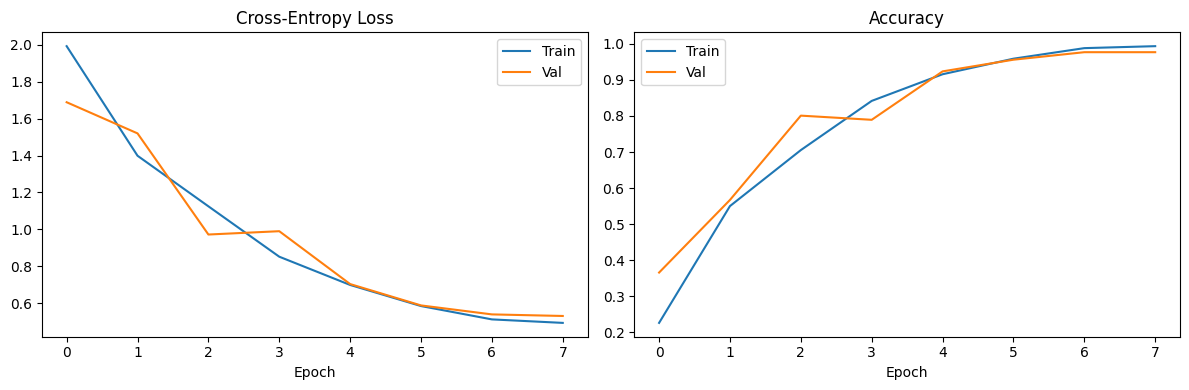

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_title('Cross-Entropy Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'],   label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Test Set Evaluation

In [ ]:
# Load best checkpoint before testing
model.load_state_dict(torch.load('best_wav2vec2_ser.pt', map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc='Testing'):
        inputs = inputs.to(DEVICE)
        logits = model(inputs)
        preds  = logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(f'Test accuracy: {accuracy_score(all_labels, all_preds):.4f}\n')
print(classification_report(all_labels, all_preds, target_names=le.classes_))

Testing: 100%|██████████| 27/27 [00:20<00:00,  1.30it/s]

Test accuracy: 0.9838

              precision    recall  f1-score   support

       angry       1.00      0.98      0.99        57
        calm       1.00      0.98      0.99        57
     disgust       1.00      1.00      1.00        58
        fear       1.00      0.97      0.98        58
       happy       0.97      0.97      0.97        58
     neutral       0.88      1.00      0.94        29
         sad       1.00      0.98      0.99        57
   surprised       0.98      1.00      0.99        58

    accuracy                           0.98       432
   macro avg       0.98      0.98      0.98       432
weighted avg       0.98      0.98      0.98       432



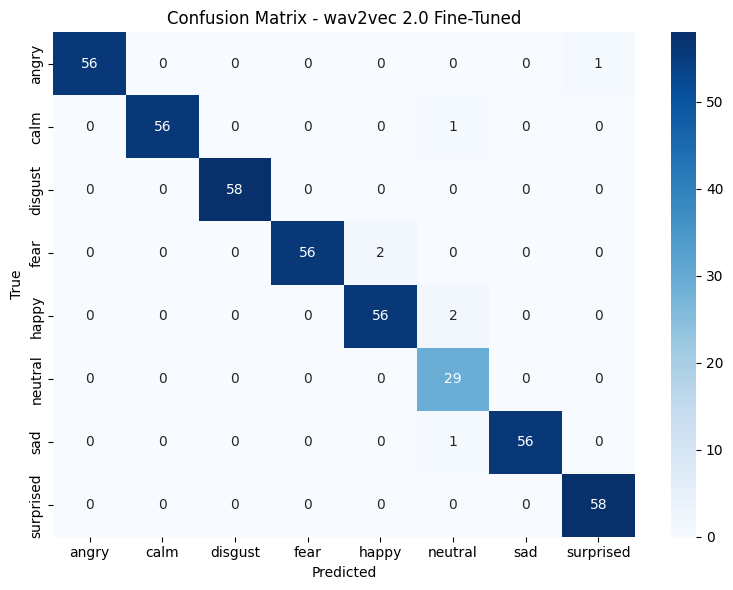

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('Confusion Matrix - wav2vec 2.0 Fine-Tuned')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.show()

## 12. Save Artifacts for Notebook 3

In [ ]:
import joblib

# Save label encoder so Notebook 3 can decode numeric predictions
joblib.dump(le, 'wav2vec2_label_encoder.pkl')

# Save model config (number of classes) alongside the weights
import json
config = {
    'model_name': MODEL_NAME,
    'num_classes': NUM_CLASSES,
    'max_length': MAX_LENGTH,
    'target_sr': TARGET_SR,
    'class_names': list(le.classes_)
}
with open('wav2vec2_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('Saved: best_wav2vec2_ser.pt, wav2vec2_label_encoder.pkl, wav2vec2_config.json')

Saved: best_wav2vec2_ser.pt, wav2vec2_label_encoder.pkl, wav2vec2_config.json
